In [2]:
# import joblib
# import os

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix, classification_report

# import lightgbm as lgb
# import shap
# import optuna

# print("All libraries imported successfully.")

# # --- Configuration Constants ---
# TRAIN_PATH = "./data/AppML_InitialProject_train.h5"
# TEST_PATH = "./data/AppML_InitialProject_test_classification.h5"
# TARGET_COLUMN = 'p_Truth_isElectron'
# # Define columns that are NOT features (e.g., other truth variables, IDs)
# # Add 'p_Truth_Energy' or any other non-feature columns if they exist in your HDF5 files.
# # If your HDF5 files only contain the target and the 140 features, this can be an empty list.
# EXCLUDE_COLUMNS = ['p_Truth_Energy'] # Example, adjust if necessary

# RANDOM_SEED = 42
# N_OPTUNA_TRIALS = 50  # Number of trials for Optuna hyperparameter search
# MAX_FEATURES_TO_USE = 25 # Max features allowed as per project constraint
# CV_FOLDS = 5 # Number of folds for cross-validation

# # Create directory for saving models and preprocessors
# os.makedirs("ml_pipeline_outputs", exist_ok=True)
# MODEL_SAVE_PATH = "ml_pipeline_outputs/final_lgbm_model.txt"
# SELECTED_FEATURES_PATH = "ml_pipeline_outputs/selected_features.joblib"
# SCALER_PATH = "ml_pipeline_outputs/scaler.joblib"
# OUTLIER_BOUNDS_PATH = "ml_pipeline_outputs/outlier_bounds.joblib"

# # --- 1. Data Loading and Initial Split ---
# print("1. Loading data...")
# try:
#     # Attempt to read the entire HDF5 file; common if data is under a single key or default
#     # You might need to specify a key if your HDF5 is structured, e.g., pd.read_hdf(TRAIN_PATH, key='mydata')
#     train_df = pd.read_hdf(TRAIN_PATH)
#     test_df_full = pd.read_hdf(TEST_PATH)
# except Exception as e:
#     print(f"Error loading HDF5 directly. Attempting to find keys if it's a store...")
#     print(f"Details: {e}")
#     try:
#         with pd.HDFStore(TRAIN_PATH, 'r') as store:
#             if not store.keys():
#                 raise ValueError(f"No datasets found in HDF5 file: {TRAIN_PATH}")
#             # Assuming the relevant data is under the first key if multiple exist and not specified
#             train_key = store.keys()[0]
#             print(f"Using key '{train_key}' for training data.")
#             train_df = store[train_key]

#         with pd.HDFStore(TEST_PATH, 'r') as store:
#             if not store.keys():
#                 raise ValueError(f"No datasets found in HDF5 file: {TEST_PATH}")
#             test_key = store.keys()[0]
#             print(f"Using key '{test_key}' for test data.")
#             test_df_full = store[test_key]
#     except Exception as e_store:
#         print(f"Failed to load data even with HDFStore. Please check HDF5 file structure and keys.")
#         print(f"Store error details: {e_store}")
#         raise

# # Define initial feature columns
# all_columns = train_df.columns.tolist()
# initial_feature_cols = [col for col in all_columns if col != TARGET_COLUMN and col not in EXCLUDE_COLUMNS]

# X = train_df[initial_feature_cols]
# y = train_df[TARGET_COLUMN]

# # Split training data into training and validation sets (for local validation before final test)
# X_train_full, X_val_full, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
# )
# print(f"Training features shape: {X_train_full.shape}")
# print(f"Validation features shape: {X_val_full.shape}")
# print(f"Test features shape: {test_df_full[initial_feature_cols].shape}")
# print(f"\nTarget distribution in training set:\n{y_train.value_counts(normalize=True)}")

1. Loading original training data...

Splitting data into Train (68%), Validation (17%), and Development Test (15%)...
  Shape of X_test_dev (from original train data): (27000, 140), y_test_dev: (27000,)
  Shape of X_train (for fitting preprocessors & main training): (116999, 140), y_train: (116999,)
  Shape of X_val (for development validation/early stopping): (36001, 140), y_val: (36001,)

Target distribution in y_train:
p_Truth_isElectron
0    0.789998
1    0.210002
Name: proportion, dtype: float64

2. Pre-processing: Applying StandardScaler directly (fitting on X_train)...
   StandardScaler fitted on X_train and applied.
   Scaler applied to X_val and X_test_dev.
   Fitted scaler saved to ml_pipeline_outputs/scaler.joblib

--- Pre-processing with Direct Scaling complete ---
X_train_scaled head:
        averageInteractionsPerCrossing   p_Rhad1    p_Rhad      p_f3  \
96942                         0.488180 -0.424994 -0.502890  0.181764   
118875                       -0.058401  0.4678

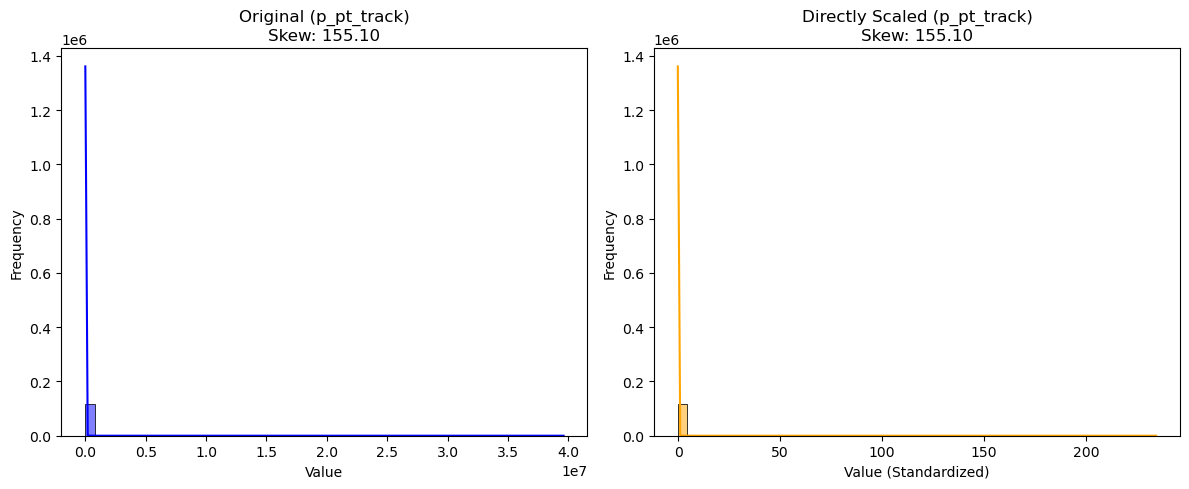

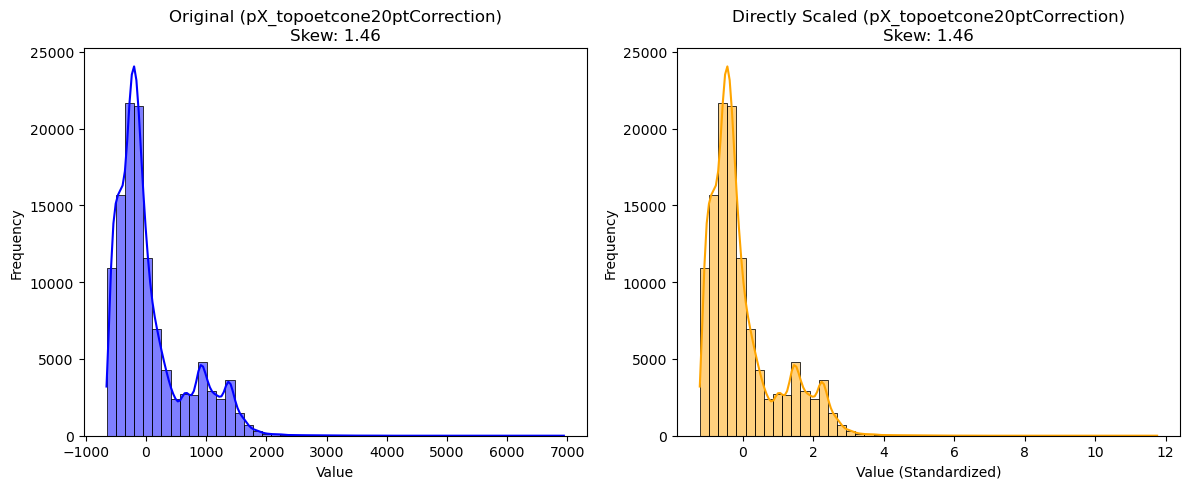

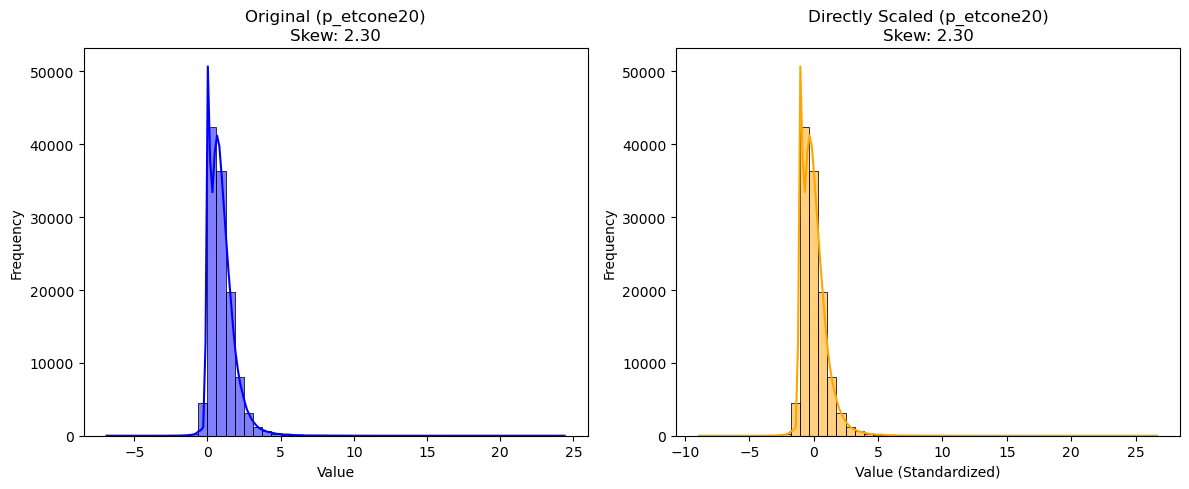


Discussion on Direct Scaling (without prior outlier treatment) - As per previous discussion, this approach preserves feature shapes while standardizing range. For LightGBM, this is often acceptable.


In [ ]:
import pandas as pd
import numpy as np
import joblib 
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

import lightgbm as lgb # Will be needed for Step 3
import shap # Will be needed for Step 3
import optuna # For hyperparameter optimization


# --- Configuration Constants ---
# Updated TEST_PATH as per your instruction
TRAIN_PATH = "./data/AppML_InitialProject_train.h5"
TEST_PATH = "./data/AppML_InitialProject_test_classification.h5" 
TARGET_COLUMN = 'p_Truth_isElectron'
EXCLUDE_COLUMNS = ['p_Truth_Energy'] # Adjust if 'p_Truth_Energy' IS a feature or other non-features exist

RANDOM_SEED = 42
VALIDATION_SIZE = 0.20 # For the validation set split from the initial training data
DEV_TEST_SIZE = 0.15   # For the development test set split from the initial training data

# Create directory for saving models and preprocessors
os.makedirs("ml_pipeline_outputs", exist_ok=True)
# Simplified names for saved preprocessors
SCALER_SAVE_PATH = "ml_pipeline_outputs/scaler.joblib"
# OUTLIER_BOUNDS_SAVE_PATH = "ml_pipeline_outputs/outlier_bounds.joblib" # Not used if we don't cap/remove

# --- 1. Data Loading and Initial 3-Way Split ---
print("1. Loading original training data...")
try:
    # Attempt to read the HDF5 file. Pandas can often infer the key if there's only one dataset.
    # If your HDF5 file has multiple datasets, you might need to specify a 'key'.
    original_train_df = pd.read_hdf(TRAIN_PATH) 
except FileNotFoundError:
    print(f"ERROR: Training data file not found at {TRAIN_PATH}")
    raise
except Exception as e:
    print(f"Error loading HDF5: {e}. Ensure the file path is correct and the file is a valid HDF5 format readable by pandas.")
    print("If your HDF5 file contains multiple datasets, you might need to specify a 'key' argument in pd.read_hdf(TRAIN_PATH, key='your_dataset_key').")
    raise


all_cols = original_train_df.columns.tolist()
feature_cols = [col for col in all_cols if col != TARGET_COLUMN and col not in EXCLUDE_COLUMNS]
if not feature_cols:
    raise ValueError("No feature columns identified after excluding target and other specified columns.")

X_original = original_train_df[feature_cols]
y_original = original_train_df[TARGET_COLUMN]

print(f"\nSplitting data into Train ({1-(DEV_TEST_SIZE + VALIDATION_SIZE*(1-DEV_TEST_SIZE)):.0%}), Validation ({VALIDATION_SIZE*(1-DEV_TEST_SIZE):.0%}), and Development Test ({DEV_TEST_SIZE:.0%})...")

# Step 1: Split off the Development Test set from the original training data
X_dev_temp, X_test_dev, y_dev_temp, y_test_dev = train_test_split(
    X_original, y_original, test_size=DEV_TEST_SIZE, random_state=RANDOM_SEED, stratify=y_original
)
print(f"  Shape of X_test_dev (from original train data): {X_test_dev.shape}, y_test_dev: {y_test_dev.shape}")

# Step 2: Split the remaining data (X_dev_temp) into Training (for fitting preprocessors, SHAP, Optuna) and Validation sets
val_size_adjusted = VALIDATION_SIZE / (1 - DEV_TEST_SIZE) 
X_train, X_val, y_train, y_val = train_test_split(
    X_dev_temp, y_dev_temp, test_size=val_size_adjusted, random_state=RANDOM_SEED, stratify=y_dev_temp
)

print(f"  Shape of X_train (for fitting preprocessors & main training): {X_train.shape}, y_train: {y_train.shape}")
print(f"  Shape of X_val (for development validation/early stopping): {X_val.shape}, y_val: {y_val.shape}")

print(f"\nTarget distribution in y_train:\n{y_train.value_counts(normalize=True)}")


# --- 2. Pre-processing: Direct Scaling (Fitting on X_train) ---
print("\n2. Pre-processing: Applying StandardScaler directly (fitting on X_train)...")

# Work with copies for processing to keep original X_train, X_val, X_test_dev intact if needed
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_dev_scaled = X_test_dev.copy()

# Assuming all features in feature_cols are numerical and should be scaled.
# If you have categorical features identified, they would need separate encoding
# and you would adjust 'numerical_cols_to_scale' accordingly.
numerical_cols_to_scale = X_train.columns.tolist() 

scaler = StandardScaler()

if numerical_cols_to_scale:
    # Fit scaler ONLY on X_train and transform it
    X_train_scaled[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
    print("   StandardScaler fitted on X_train and applied.")

    # Apply the FITTED scaler to validation and dev-test sets
    if hasattr(scaler, 'mean_'): # Check if scaler was actually fit
        if not X_val.empty:
             X_val_scaled[numerical_cols_to_scale] = scaler.transform(X_val[numerical_cols_to_scale])
        if not X_test_dev.empty:
            X_test_dev_scaled[numerical_cols_to_scale] = scaler.transform(X_test_dev[numerical_cols_to_scale])
        print("   Scaler applied to X_val and X_test_dev.")
        
        # Save the fitted scaler
        joblib.dump(scaler, SCALER_SAVE_PATH)
        print(f"   Fitted scaler saved to {SCALER_SAVE_PATH}")
else:
    print("   No numerical columns identified/selected to scale.")
    scaler = None # Ensure scaler is None if not fitted

print("\n--- Pre-processing with Direct Scaling complete ---")
print("X_train_scaled head:")
print(X_train_scaled.head())


# --- 2.5 Visualizing Data After Direct Scaling ---
print("\n2.5 Visualizing selected features: Original vs. Directly Scaled...")

example_feature_vis = 'pX_topoetcone20ptCorrection' 
if example_feature_vis not in feature_cols: # Check if it was in the original feature list
    if len(feature_cols) > 0:
        example_feature_vis = feature_cols[0] 
    else:
        example_feature_vis = None
        print("No features available for visualization.")

features_to_visualize_list = []
if example_feature_vis:
    features_to_visualize_list.append(example_feature_vis)

# Add a couple more random features if available
if len(feature_cols) > 1:
    available_other_features = [col for col in feature_cols if col != example_feature_vis and col in X_train.columns]
    if available_other_features:
        other_features_vis = np.random.choice(
            available_other_features, 
            size=min(2, len(available_other_features)), 
            replace=False
        )
        features_to_visualize_list.extend(other_features_vis)

features_to_visualize_list = list(set(features_to_visualize_list)) # Ensure unique

print(f"   Will visualize: {features_to_visualize_list}")

for feature_name_to_vis in features_to_visualize_list:
    if feature_name_to_vis not in X_train.columns:
        print(f"Feature {feature_name_to_vis} not found in X_train, skipping visualization.")
        continue
        
    plt.figure(figsize=(12, 5))

    # 1. Original Data from X_train (before scaling)
    plt.subplot(1, 2, 1)
    sns.histplot(X_train[feature_name_to_vis], kde=True, color='blue', bins=50)
    plt.title(f'Original ({feature_name_to_vis})\nSkew: {X_train[feature_name_to_vis].skew():.2f}')
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    # 2. Processed Data (Directly Scaled from X_train_scaled)
    plt.subplot(1, 2, 2)
    if feature_name_to_vis in X_train_scaled.columns: # Ensure column exists after scaling
        sns.histplot(X_train_scaled[feature_name_to_vis], kde=True, color='orange', bins=50)
        plt.title(f'Directly Scaled ({feature_name_to_vis})\nSkew: {X_train_scaled[feature_name_to_vis].skew():.2f}')
        plt.xlabel("Value (Standardized)")
        plt.ylabel("Frequency")
    else:
         plt.title(f'Directly Scaled ({feature_name_to_vis}) - Not found')

    plt.tight_layout()
    plt.show()

print("\nDiscussion on Direct Scaling (without prior outlier treatment) - As per previous discussion, this approach preserves feature shapes while standardizing range. For LightGBM, this is often acceptable.")

# Key variables available for next steps:
# X_train_scaled, y_train (for SHAP, Optuna, final model training on this part)
# X_val_scaled, y_val (for early stopping of final model, or as a separate dev validation)
# X_test_dev_scaled, y_test_dev (for evaluating the developed model before final test)
# scaler (the StandardScaler fitted on X_train[numerical_cols_to_scale])
# feature_cols (list of all original feature names)


--- Part 3: Fitting Preliminary LightGBM Model (for SHAP Analysis) ---
    (Using user-provided working structure for LGBMClassifier and .fit())
Calculated scale_pos_weight for SHAP model: 3.76
Fitting preliminary LightGBM model for SHAP analysis...


[LightGBM] [Info] Number of positive: 24570, number of negative: 92429
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 29794
[LightGBM] [Info] Number of data points in the train set: 116999, number of used features: 136
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.210002 -> initscore=-1.324915
[LightGBM] [Info] Start training from score -1.324915
Preliminary LightGBM model fitted successfully.

--- Part 3.5: SHAP Analysis & Feature Ranking ---
Generating SHAP values...


/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



Top 10 SHAP ranked features (from scaled data):
['p_sigmad0', 'p_TRTPID', 'p_etcone20', 'pX_MultiLepton', 'pX_deltaEta1', 'p_ptPU30', 'p_dPOverP', 'p_deltaEta1', 'p_Rhad', 'p_numberOfInnermostPixelHits']

Generating SHAP summary plot...
SHAP summary plot saved to ml_pipeline_outputs/shap_summary_plot.pdf


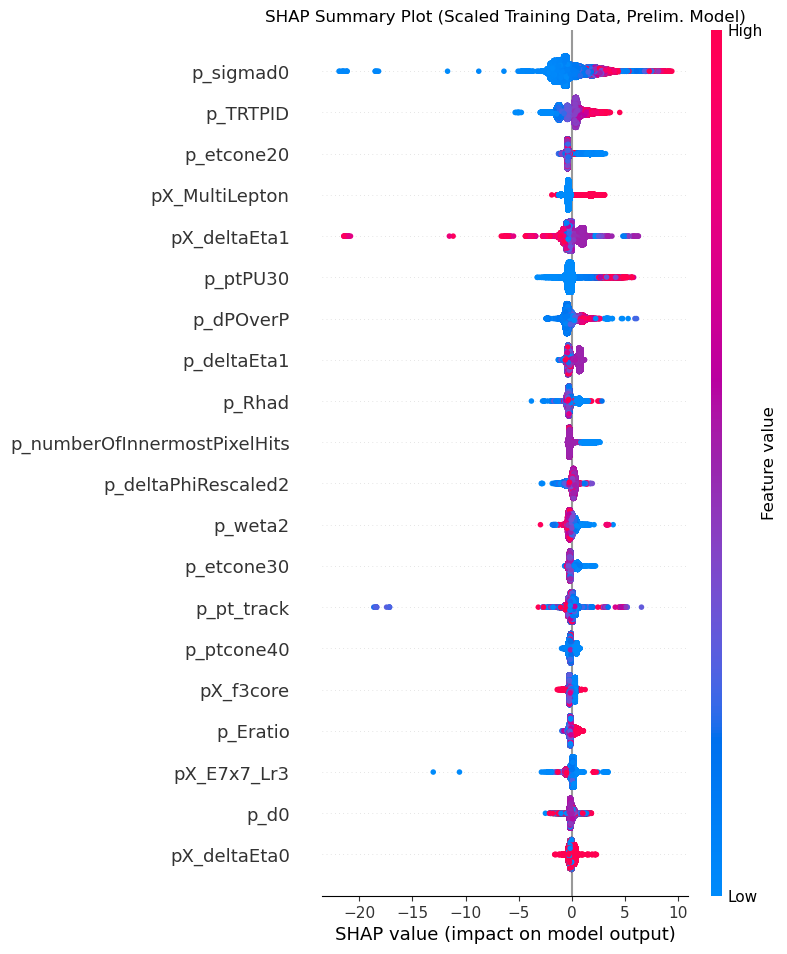

In [4]:
# For this block, we assume X_train_scaled, y_train, X_val_scaled, y_val, 
# and RANDOM_SEED are correctly defined and available.
# Example check (in a real notebook, these would be inherited):
if 'X_train_scaled' not in locals() or 'y_train' not in locals() or \
   'X_val_scaled' not in locals() or 'y_val' not in locals() or \
   'RANDOM_SEED' not in locals():
    print("ERROR: One or more required variables (X_train_scaled, y_train, X_val_scaled, y_val, RANDOM_SEED) not found.")
    print("Please ensure data loading, splitting, and scaling steps (1, 2, 2.5) are run before this cell.")
    # You might want to raise an error or stop execution here in a real script/notebook.
    # For demonstration, we'll try to proceed but it will likely fail if data is missing.
    raise NameError("Missing required data from previous steps.") # Uncomment to enforce


print("\n--- Part 3: Fitting Preliminary LightGBM Model (for SHAP Analysis) ---")
print("    (Using user-provided working structure for LGBMClassifier and .fit())")

# 1. Calculate scale_pos_weight for class imbalance
if y_train.value_counts().get(1, 0) > 0 and y_train.value_counts().get(0, 0) > 0:
    scale_pos_weight_shap = y_train.value_counts().loc[0] / y_train.value_counts().loc[1]
else:
    scale_pos_weight_shap = 1
    print("Warning: Could not calculate scale_pos_weight accurately. Defaulting to 1.")
print(f"Calculated scale_pos_weight for SHAP model: {scale_pos_weight_shap:.2f}")

# 2. Instantiate LGBMClassifier with parameters passed directly
#    Following the user's working example.
#    Note: 'metric' is NOT in the constructor here.
#    'num_iterations' is an alias for 'n_estimators'.
prelim_model_for_shap = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    random_state=RANDOM_SEED,
    scale_pos_weight=scale_pos_weight_shap,
    num_leaves=11,
    n_jobs=-1,
    verbosity=1, # As per user's example, will print LightGBM training info
    n_estimators=500, # Using n_estimators, standard scikit-learn alias for num_iterations
    learning_rate=0.5,
)

print("Fitting preliminary LightGBM model for SHAP analysis...")
try:
    # Call .fit() with X, y, eval_set, eval_metric, and callbacks as arguments
    prelim_model_for_shap.fit(
        X_train_scaled,
        y_train,
        eval_set=[(X_val_scaled, y_val)],
        eval_metric='roc_auc', # <<< eval_metric explicitly in .fit()
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )
    print("Preliminary LightGBM model fitted successfully.")
except ValueError as ve:
    print(f"ValueError during fit: {ve}")
    print("If this error persists, double-check data shapes, types, and ensure all eval sets are non-empty.")
    raise
except Exception as e:
    print(f"An unexpected error occurred during prelim_model_for_shap.fit(): {e}")
    raise

# --- Part 3.5: SHAP Analysis (using the fitted model from Part 3) ---
print("\n--- Part 3.5: SHAP Analysis & Feature Ranking ---")

if not hasattr(prelim_model_for_shap, '_Booster') or prelim_model_for_shap._Booster is None:
    raise RuntimeError("prelim_model_for_shap does not appear to be fitted. Please check Part 3.")

print("Generating SHAP values...")
explainer = shap.TreeExplainer(prelim_model_for_shap)
shap_values_raw = explainer.shap_values(X_train_scaled)

if isinstance(shap_values_raw, list) and len(shap_values_raw) == 2:
    shap_values_positive_class = shap_values_raw[1]
else:
    shap_values_positive_class = shap_values_raw

mean_abs_shap = np.mean(np.abs(shap_values_positive_class), axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': mean_abs_shap
}).sort_values(by='importance', ascending=False)

all_shap_ranked_features = shap_importance_df['feature'].tolist()

print(f"\nTop 10 SHAP ranked features (from scaled data):\n{all_shap_ranked_features[:10]}")

print("\nGenerating SHAP summary plot...")
shap.summary_plot(shap_values_positive_class, X_train_scaled, show=False)
plt.title("SHAP Summary Plot (Scaled Training Data, Prelim. Model)")
output_dir = "ml_pipeline_outputs"
os.makedirs(output_dir, exist_ok=True) # Ensure directory exists
summary_plot_path = os.path.join(output_dir, "shap_summary_plot.pdf")
plt.savefig(summary_plot_path, bbox_inches='tight')
# plt.clf()
print(f"SHAP summary plot saved to {summary_plot_path}")
plt.show()

# Key outputs for next steps: all_shap_ranked_features


In [6]:
print("SHAP Importance DataFrame (Top 15):")
print(shap_importance_df.head(15))

SHAP Importance DataFrame (Top 15):
                          feature  importance
18                      p_sigmad0    1.315311
9                        p_TRTPID    0.865958
22                     p_etcone20    0.649415
42                 pX_MultiLepton    0.549500
50                   pX_deltaEta1    0.511366
28                       p_ptPU30    0.504835
19                      p_dPOverP    0.492488
20                    p_deltaEta1    0.374646
2                          p_Rhad    0.344653
10   p_numberOfInnermostPixelHits    0.342890
21            p_deltaPhiRescaled2    0.253922
4                         p_weta2    0.227623
23                     p_etcone30    0.220758
136                    p_pt_track    0.208409
27                     p_ptcone40    0.206279


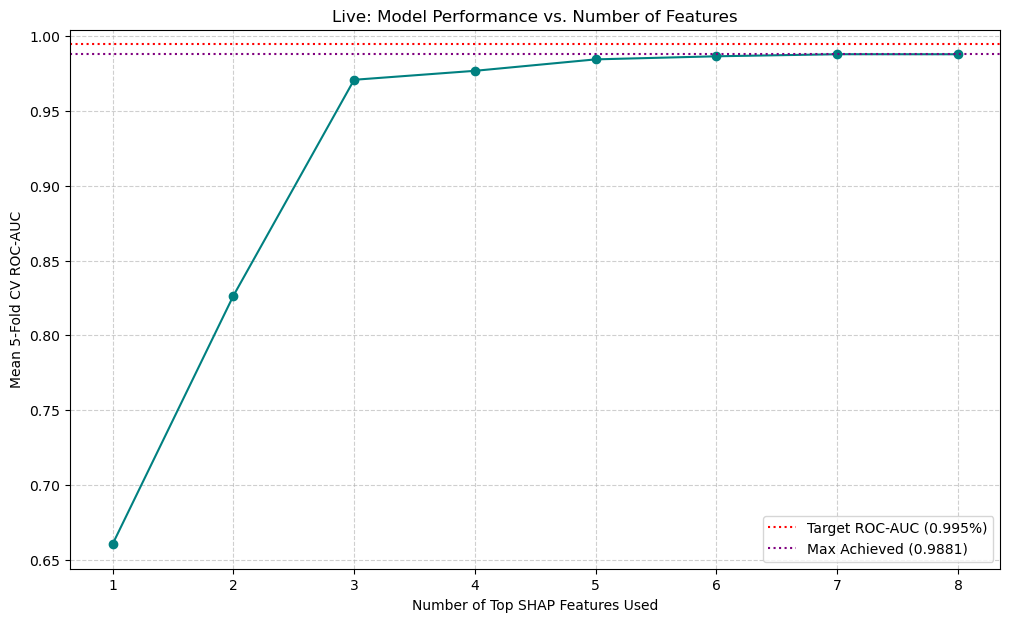

    No significant improvement for 3 step(s). Best ROC-AUC remains ~0.9846.

Early stopping triggered for the outer loop: No significant ROC-AUC improvement for 3 consecutive feature additions.
Stopping feature iteration at 8 features.

Final Performance vs. Number of Features plot saved to ml_pipeline_outputs/roc_auc_vs_n_features_early_stopped_final.png

Summary of ROC-AUC scores vs. Number of Features (potentially early stopped):
  Features:  1, ROC-AUC: 0.6603
  Features:  2, ROC-AUC: 0.8264
  Features:  3, ROC-AUC: 0.9710
  Features:  4, ROC-AUC: 0.9770
  Features:  5, ROC-AUC: 0.9846
  Features:  6, ROC-AUC: 0.9867
  Features:  7, ROC-AUC: 0.9881
  Features:  8, ROC-AUC: 0.9880

--- Step 4 Complete ---


<Figure size 1200x700 with 0 Axes>

In [9]:
from IPython.display import display, clear_output # For live updating plot

# --- Configuration for this Step (ensure these are set) ---
if 'CV_FOLDS' not in locals():
    CV_FOLDS = 5
    print(f"CV_FOLDS not found, defaulting to {CV_FOLDS}")
if 'MAX_FEATURES_FOR_ANALYSIS' not in locals():
    MAX_FEATURES_FOR_ANALYSIS = 25 
    print(f"MAX_FEATURES_FOR_ANALYSIS not found, defaulting to {MAX_FEATURES_FOR_ANALYSIS}")
if 'RANDOM_SEED' not in locals():
    RANDOM_SEED = 42
    print(f"RANDOM_SEED not found, defaulting to {RANDOM_SEED}")


# --- Threshold and Early Stopping Parameters ---
ACCEPTABLE_ROC_AUC_THRESHOLD = 0.98 # Define the acceptable ROC-AUC threshold
# This value was mentioned in the research document (ID: 70f63916-a133-404e-9198-ba03a2335d53, Section 4.3)
# as a reasonable starting point for discussion. Adjust as needed.
OUTER_LOOP_EARLY_STOPPING_PATIENCE = 3 
MIN_ROC_AUC_IMPROVEMENT = 0.005     

# Check if essential variables from previous steps exist
if 'X_train_scaled' not in locals() or \
   'y_train' not in locals() or \
   'all_shap_ranked_features' not in locals():
    print("ERROR: One or more required variables (X_train_scaled, y_train, all_shap_ranked_features) not found.")
    raise NameError("Missing required data from previous steps for Step 4.")

print("\n--- Step 4: Iterative Feature Performance Analysis (with Live Updating Plot & Early Stopping) ---")
print(f"Using ACCEPTABLE_ROC_AUC_THRESHOLD: {ACCEPTABLE_ROC_AUC_THRESHOLD}")

roc_auc_scores_vs_n_features = []
n_features_tested_list = [] 

n_features_upper_bound = min(len(all_shap_ranked_features), MAX_FEATURES_FOR_ANALYSIS)
if n_features_upper_bound < 1:
    raise ValueError("No features available or MAX_FEATURES_FOR_ANALYSIS is less than 1.")
n_features_range_potential = range(1, n_features_upper_bound + 1)

if y_train.value_counts().get(1, 0) > 0 and y_train.value_counts().get(0, 0) > 0:
    scale_pos_weight_iterative = y_train.value_counts().loc[0] / y_train.value_counts().loc[1]
else:
    scale_pos_weight_iterative = 1
print(f"Using scale_pos_weight: {scale_pos_weight_iterative:.2f} for iterative models in CV.")

best_roc_auc_so_far = -np.inf
steps_without_improvement = 0

# Create a figure and axis object for the live plot
fig_live, ax_live = plt.subplots(figsize=(12, 7))

for k_features in n_features_range_potential:
    current_top_k_features = all_shap_ranked_features[:k_features]
    X_subset_for_cv = X_train_scaled[current_top_k_features]
    
    print(f"  Testing with top {k_features} features. First 3: {current_top_k_features[:3]}...")
    n_features_tested_list.append(k_features)

    cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_roc_auc_scores = [] 

    for fold_num, (train_idx, val_idx) in enumerate(cv_splitter.split(X_subset_for_cv, y_train)):
        X_train_fold, X_val_fold = X_subset_for_cv.iloc[train_idx], X_subset_for_cv.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model_iterative = lgb.LGBMClassifier(
            boosting_type='gbdt', objective='binary', random_state=RANDOM_SEED + fold_num,
            scale_pos_weight=scale_pos_weight_iterative, num_leaves=11,
            n_jobs=-1, verbosity=-1, n_estimators=300, learning_rate=0.05
        )
        
        try:
            model_iterative.fit(
                X_train_fold, y_train_fold,
                eval_set=[(X_val_fold, y_val_fold)], eval_metric='roc_auc',
                callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)] 
            )
        except Exception as e:
            print(f"    Error fitting model in fold {fold_num+1} for {k_features} features: {e}")
            fold_roc_auc_scores.append(np.nan) 
            continue

        preds_proba_val_fold = model_iterative.predict_proba(X_val_fold)[:, 1]
        roc_auc_val_fold = roc_auc_score(y_val_fold, preds_proba_val_fold)
        fold_roc_auc_scores.append(roc_auc_val_fold)

    mean_cv_roc_auc = np.nanmean(fold_roc_auc_scores)
    roc_auc_scores_vs_n_features.append(mean_cv_roc_auc)
    print(f"    Mean {CV_FOLDS}-Fold CV ROC-AUC for {k_features} features: {mean_cv_roc_auc:.4f}")

    # --- Live Plot Update ---
    ax_live.clear() # Clear the previous drawing on the axis
    ax_live.plot(n_features_tested_list, roc_auc_scores_vs_n_features, marker='o', linestyle='-', color='teal')
    ax_live.set_xlabel("Number of Top SHAP Features Used")
    ax_live.set_ylabel(f"Mean {CV_FOLDS}-Fold CV ROC-AUC")
    ax_live.set_title("Live: Model Performance vs. Number of Features")
    
    if n_features_tested_list:
        max_feat_tested = max(n_features_tested_list)
        tick_step_live = 1 if max_feat_tested <=10 else 2 if max_feat_tested <=20 else int(np.ceil(max_feat_tested/10))
        ax_live.set_xticks(list(range(min(n_features_tested_list), max_feat_tested + 1, tick_step_live)))
    
    ax_live.grid(True, linestyle='--', alpha=0.6)
    # Optional: add horizontal lines to the live plot too
    ax_live.axhline(y=ACCEPTABLE_ROC_AUC_THRESHOLD, color='green', linestyle='--', label=f'Acceptable ROC-AUC ({ACCEPTABLE_ROC_AUC_THRESHOLD})')
    # ax_live.axhline(y=0.980, color='r', linestyle=':', label='Target ROC-AUC (0.995%)')
    if roc_auc_scores_vs_n_features:
        ax_live.axhline(y=max(roc_auc_scores_vs_n_features), color='purple', linestyle=':', 
                        label=f'Max Achieved ({max(roc_auc_scores_vs_n_features):.4f})')
    ax_live.legend(loc='lower right')
    
    clear_output(wait=True) # Clear the output of the current cell, wait for new output
    display(fig_live)      # Display the updated figure
    plt.pause(0.1)         # Pause briefly to allow the plot to render
    # --- End Live Plot Update ---

    # Outer loop early stopping logic
    if mean_cv_roc_auc > best_roc_auc_so_far + MIN_ROC_AUC_IMPROVEMENT:
        best_roc_auc_so_far = mean_cv_roc_auc
        steps_without_improvement = 0
        print(f"    New best ROC-AUC: {best_roc_auc_so_far:.4f}")
    else:
        steps_without_improvement += 1
        print(f"    No significant improvement for {steps_without_improvement} step(s). Best ROC-AUC remains ~{best_roc_auc_so_far:.4f}.")

    if steps_without_improvement >= OUTER_LOOP_EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered for the outer loop: No significant ROC-AUC improvement for {OUTER_LOOP_EARLY_STOPPING_PATIENCE} consecutive feature additions.")
        print(f"Stopping feature iteration at {k_features} features.")
        break 

# --- Final Plotting (after loop finishes or early stops) ---
# Close the live plot figure to avoid duplicate output if plt.show() is used later by user
plt.close(fig_live) 

# Generate the final static plot
final_fig, final_ax = plt.subplots(figsize=(12, 7))
final_ax.plot(n_features_tested_list, roc_auc_scores_vs_n_features, marker='o', linestyle='-', color='teal', label=f'Mean {CV_FOLDS}-Fold ROC-AUC')
final_ax.set_xlabel("Number of Top SHAP Features Used")
final_ax.set_ylabel(f"Mean {CV_FOLDS}-Fold CV ROC-AUC")
final_ax.set_title("Final: Model Performance vs. Number of Features (Early Stopping Active)")

if n_features_tested_list:
    max_feat_final = max(n_features_tested_list)
    tick_step_final = 1 if max_feat_final <=10 else 2 if max_feat_final <=20 else int(np.ceil(max_feat_final/10))
    final_ax.set_xticks(list(range(min(n_features_tested_list), max_feat_final + 1, tick_step_final)))

final_ax.grid(True, linestyle='--', alpha=0.6)
final_ax.axhline(y=ACCEPTABLE_ROC_AUC_THRESHOLD, color='green', linestyle='--', label=f'Acceptable ROC-AUC ({ACCEPTABLE_ROC_AUC_THRESHOLD})')
if roc_auc_scores_vs_n_features: 
    final_ax.axhline(y=max(roc_auc_scores_vs_n_features), color='purple', linestyle=':', 
                     label=f'Max Achieved ROC-AUC ({max(roc_auc_scores_vs_n_features):.4f})')
final_ax.legend(loc='lower right')
plt.tight_layout()

output_dir = "ml_pipeline_outputs"
os.makedirs(output_dir, exist_ok=True)
performance_plot_path_es_final = os.path.join(output_dir, "roc_auc_vs_n_features_early_stopped_final.pdf")
plt.savefig(performance_plot_path_es_final)
plt.show() # If you want to display it in the notebook after the loop
# plt.clf() 
print(f"\nFinal Performance vs. Number of Features plot saved to {performance_plot_path_es_final}")

print("\nSummary of ROC-AUC scores vs. Number of Features (potentially early stopped):")
for k_val, score_val in zip(n_features_tested_list, roc_auc_scores_vs_n_features):
    print(f"  Features: {k_val:2d}, ROC-AUC: {score_val:.4f}")

print("\n--- Step 4 Complete ---")


# Key outputs from this step to inform next decisions:
# - The final plot: 'roc_auc_vs_n_features_early_stopped_final.png'
# - roc_auc_scores_vs_n_features: List of mean CV ROC-AUC scores for each number of features tested.
# - n_features_tested_list: List of the number of features (k) corresponding to each score.
# - ACCEPTABLE_ROC_AUC_THRESHOLD: The defined threshold used for evaluation.
# These will be used to automatically determine N_FEATURES_FINAL for Step 5.

In [ ]:
# This block should be run after Step 4 (lgbm_shap_pipeline_v9_step4_live_plot) is complete.
# It uses the outputs from Step 4 to determine N_FEATURES_FINAL.

# Ensure necessary variables from Step 4 are available:
if 'roc_auc_scores_vs_n_features' not in locals() or \
   'n_features_tested_list' not in locals() or \
   'ACCEPTABLE_ROC_AUC_THRESHOLD' not in locals():
    print("ERROR: Outputs from Step 4 (roc_auc_scores_vs_n_features, n_features_tested_list, ACCEPTABLE_ROC_AUC_THRESHOLD) not found.")
    # Define fallback values for demonstration if running standalone, but this is not ideal.
    raise NameError("Missing required data from Step 4 to determine N_FEATURES_FINAL.")


N_FEATURES_FINAL = 0 # Initialize
achieved_threshold_score = -1.0

if not roc_auc_scores_vs_n_features or not n_features_tested_list:
    raise ValueError("Warning: ROC AUC scores or features tested list is empty. Cannot determine N_FEATURES_FINAL automatically.")
    # print("Warning: ROC AUC scores or features tested list is empty. Cannot determine N_FEATURES_FINAL automatically.")
    # print(f"Defaulting N_FEATURES_FINAL to a conservative value, e.g., 5, or MAX_FEATURES_FOR_ANALYSIS ({MAX_FEATURES_FOR_ANALYSIS if 'MAX_FEATURES_FOR_ANALYSIS' in locals() else 'not set'}).")
    # Fallback strategy: if MAX_FEATURES_FOR_ANALYSIS is defined, use it, else a small number.
    # N_FEATURES_FINAL = min(5, MAX_FEATURES_FOR_ANALYSIS if 'MAX_FEATURES_FOR_ANALYSIS' in locals() else 5)

else:
    for i, score in enumerate(roc_auc_scores_vs_n_features):
        num_features = n_features_tested_list[i]
        if score >= ACCEPTABLE_ROC_AUC_THRESHOLD:
            N_FEATURES_FINAL = num_features
            achieved_threshold_score = score
            print(f"Found {N_FEATURES_FINAL} features achieving ROC-AUC {score:.4f} (>= threshold {ACCEPTABLE_ROC_AUC_THRESHOLD}).")
            break # Stop at the first (smallest) number of features that meets the threshold
    
    if N_FEATURES_FINAL == 0: # Threshold not met by any feature count tested
        print(f"Acceptable ROC-AUC threshold ({ACCEPTABLE_ROC_AUC_THRESHOLD}) not met by any feature count up to {max(n_features_tested_list) if n_features_tested_list else 'N/A'} features.")
        # Fallback: use the number of features that gave the best score, up to MAX_FEATURES_FOR_ANALYSIS
        if roc_auc_scores_vs_n_features:
            best_score_idx = np.argmax(roc_auc_scores_vs_n_features)
            N_FEATURES_FINAL = n_features_tested_list[best_score_idx]
            achieved_threshold_score = roc_auc_scores_vs_n_features[best_score_idx]
            print(f"Using {N_FEATURES_FINAL} features, which gave the best observed ROC-AUC: {achieved_threshold_score:.4f}.")
        else: # Should not happen if first check passed
            #  N_FEATURES_FINAL = min(5, MAX_FEATURES_FOR_ANALYSIS if 'MAX_FEATURES_FOR_ANALYSIS' in locals() else 5)
            #  print(f"Defaulting N_FEATURES_FINAL to {N_FEATURES_FINAL} due to no scores.")
             raise ValueError("Warning: No ROC AUC scores!")


# Ensure N_FEATURES_FINAL does not exceed MAX_FEATURES_FOR_ANALYSIS (project constraint)
if 'MAX_FEATURES_FOR_ANALYSIS' in locals():
    if N_FEATURES_FINAL > MAX_FEATURES_FOR_ANALYSIS:
        print(f"Warning: Determined N_FEATURES_FINAL ({N_FEATURES_FINAL}) exceeds MAX_FEATURES_FOR_ANALYSIS ({MAX_FEATURES_FOR_ANALYSIS}).")
        print(f"Adjusting N_FEATURES_FINAL to {MAX_FEATURES_FOR_ANALYSIS}.")
        N_FEATURES_FINAL = MAX_FEATURES_FOR_ANALYSIS
        # You might want to find the score for this capped N_FEATURES_FINAL if it changed
        if N_FEATURES_FINAL in n_features_tested_list:
            achieved_threshold_score = roc_auc_scores_vs_n_features[n_features_tested_list.index(N_FEATURES_FINAL)]
        else: # If MAX_FEATURES_FOR_ANALYSIS was not directly tested (e.g. early stopping before it)
            achieved_threshold_score = -1.0 # Mark as unknown for this specific count
            print(f"Score for exactly {N_FEATURES_FINAL} features was not directly computed in Step 4.")


print(f"\nAutomatically determined N_FEATURES_FINAL for Next Step: {N_FEATURES_FINAL}")
if achieved_threshold_score > 0:
    print(f"(Achieved ROC-AUC with these features: {achieved_threshold_score:.4f})")

# This N_FEATURES_FINAL will now be used by Step 5.


Found 5 features achieving ROC-AUC 0.9846 (>= threshold 0.98).

Automatically determined N_FEATURES_FINAL for Next Step: 5
(Achieved ROC-AUC with these features: 0.9846)


In [20]:
# --- Configuration for this Step (ensure these are set) ---
# N_FEATURES_FINAL is now assumed to be determined by the preceding code block.
if 'N_FEATURES_FINAL' not in locals():
    print("ERROR: N_FEATURES_FINAL not found. Please run the determination step after Step 4.")

N_OPTUNA_TRIALS = 50 # Number of trials for Optuna to run.

if 'CV_FOLDS' not in locals():
    CV_FOLDS = 5 
    print(f"CV_FOLDS not found, defaulting to {CV_FOLDS}")
if 'RANDOM_SEED' not in locals():
    RANDOM_SEED = 42
    print(f"RANDOM_SEED not found, defaulting to {RANDOM_SEED}")

# Check if essential variables from previous steps exist
if 'X_train_scaled' not in locals() or \
   'y_train' not in locals() or \
   'all_shap_ranked_features' not in locals():
    print("ERROR: One or more required variables (X_train_scaled, y_train, all_shap_ranked_features) not found.")
    raise NameError("Missing required data from previous steps for Step 5.")

print(f"\n--- Step 5: Hyperparameter Optimization with Optuna for Top {N_FEATURES_FINAL} Features ---")

# 1. Select the top N_FEATURES_FINAL features (already determined)
if len(all_shap_ranked_features) < N_FEATURES_FINAL:
    print(f"Warning: N_FEATURES_FINAL is {N_FEATURES_FINAL}, but only {len(all_shap_ranked_features)} available from SHAP ranking.")
    final_selected_features = all_shap_ranked_features[:] 
else:
    final_selected_features = all_shap_ranked_features[:N_FEATURES_FINAL]

print(f"Using selected top {len(final_selected_features)} features for Optuna: {final_selected_features}")

# 2. Prepare the training data subset for Optuna
X_train_selected_for_optuna = X_train_scaled[final_selected_features]
print(f"Shape of data for Optuna (X_train_selected_for_optuna): {X_train_selected_for_optuna.shape}")

# 3. Define the Objective Function for Optuna
if y_train.value_counts().get(1, 0) > 0 and y_train.value_counts().get(0, 0) > 0:
    global_scale_pos_weight = y_train.value_counts().loc[0] / y_train.value_counts().loc[1]
else:
    global_scale_pos_weight = 1.0

def optuna_objective(trial, X_data, y_data):
    lgbm_params = {
        'objective': 'binary', 'random_state': RANDOM_SEED, 'n_jobs': 2, 'verbosity': -1,
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 5, 50 if N_FEATURES_FINAL <=10 else 100), # Adjust based on N_FEATURES_FINAL
        'max_depth': trial.suggest_int('max_depth', 3, 8 if N_FEATURES_FINAL <=10 else 10),    # Adjust based on N_FEATURES_FINAL
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # Allow lower for fewer features
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True), 
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True), 
    }
    imbalance_handling_method = trial.suggest_categorical('imbalance_handling', ['scale_pos_weight', 'is_unbalance', 'none'])
    if imbalance_handling_method == 'scale_pos_weight':
        lgbm_params['scale_pos_weight'] = trial.suggest_float('scale_pos_weight_val', 
                                                              global_scale_pos_weight * 0.8, 
                                                              global_scale_pos_weight * 1.2)
    elif imbalance_handling_method == 'is_unbalance':
        lgbm_params['is_unbalance'] = True

    cv_splitter_optuna = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    roc_auc_scores_fold = []
    for fold_num, (train_idx, val_idx) in enumerate(cv_splitter_optuna.split(X_data, y_data)):
        X_train_fold, X_val_fold = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_train_fold, y_val_fold = y_data.iloc[train_idx], y_data.iloc[val_idx]
        model_optuna = lgb.LGBMClassifier(**lgbm_params)
        try:
            model_optuna.fit(
                X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)],
                eval_metric='roc_auc', 
                callbacks=[lgb.early_stopping(stopping_rounds=25, verbose=False)]
            )
        except Exception as e:
            print(f"    Optuna Trial {trial.number}, Fold {fold_num+1}: Error during fit - {e}")
            return -np.inf 
        preds_proba_val_fold = model_optuna.predict_proba(X_val_fold)[:, 1]
        roc_auc_val_fold = roc_auc_score(y_val_fold, preds_proba_val_fold)
        roc_auc_scores_fold.append(roc_auc_val_fold)
        trial.report(roc_auc_val_fold, step=fold_num) 
        if trial.should_prune():
            print(f"    Optuna Trial {trial.number}, Fold {fold_num+1}: Pruned.")
            raise optuna.exceptions.TrialPruned()
    mean_roc_auc_cv = np.mean(roc_auc_scores_fold)
    return mean_roc_auc_cv

# 4. Run the Optuna Study
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5, n_min_trials=10)
)
print(f"\nStarting Optuna study for {N_OPTUNA_TRIALS} trials...")
study.optimize(
    lambda trial: optuna_objective(trial, X_train_selected_for_optuna, y_train),
    n_trials=N_OPTUNA_TRIALS, n_jobs=4,
)

# 5. Retrieve and print the best hyperparameters
best_lgbm_params = study.best_params
best_roc_auc_optuna = study.best_value
print("\nOptuna study finished.")
print(f"  Best ROC-AUC from Optuna: {best_roc_auc_optuna:.4f}")
print("  Best hyperparameters found by Optuna:")
for key, value in best_lgbm_params.items(): print(f"    {key}: {value}")

imbalance_choice = best_lgbm_params.pop('imbalance_handling', None)
if imbalance_choice == 'scale_pos_weight':
    if 'scale_pos_weight_val' in best_lgbm_params:
        best_lgbm_params['scale_pos_weight'] = best_lgbm_params.pop('scale_pos_weight_val')
elif imbalance_choice == 'is_unbalance':
    best_lgbm_params['is_unbalance'] = True
if 'scale_pos_weight_val' in best_lgbm_params and 'scale_pos_weight' not in best_lgbm_params:
    best_lgbm_params.pop('scale_pos_weight_val')

print("\nCleaned best hyperparameters for final model training:")
for key, value in best_lgbm_params.items(): print(f"    {key}: {value}")
    
print("\n--- Step 5 Complete ---")

# Key outputs from this step to inform next decisions:
# - best_lgbm_params: A dictionary of the best hyperparameters found by Optuna.
# - final_selected_features: The list of feature names used for this optimization (determined by N_FEATURES_FINAL).
# These will be used in Step 6 to train the final model.



--- Step 5: Hyperparameter Optimization with Optuna for Top 5 Features ---
Using selected top 5 features for Optuna: ['p_sigmad0', 'p_TRTPID', 'p_etcone20', 'pX_MultiLepton', 'pX_deltaEta1']
Shape of data for Optuna (X_train_selected_for_optuna): (116999, 5)

Starting Optuna study for 50 trials...


/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/site-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")
/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/site-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")
/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/site-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")
/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/site-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")
/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/site-packages/lightgbm/callback.py:333: UserWarning

KeyboardInterrupt: 

In [ ]:
# # Assuming variables from previous steps are loaded and available:
# # - X_train_scaled: The scaled training feature data (pandas DataFrame).
# # - y_train: The training target data (pandas Series).
# # - all_shap_ranked_features: The list of feature names, sorted by SHAP importance.
# # - N_FEATURES_FINAL: Determined automatically after Step 4.
# # - RANDOM_SEED: For reproducibility.
# # - CV_FOLDS: Number of cross-validation folds.



# # --- Configuration for this Step (ensure these are set from previous steps) ---
# if 'N_FEATURES_FINAL' not in locals():
#     print("ERROR: N_FEATURES_FINAL not found. Please run the determination step after Step 4.")
#     # Fallback for standalone execution, but this should be set by the previous step.
#     N_FEATURES_FINAL = 5 
#     print(f"Defaulting N_FEATURES_FINAL to {N_FEATURES_FINAL} as it was not found.")

# N_OPTUNA_TRIALS = 50 # Number of trials for Optuna to run. Adjust as needed (e.g., 50-100 for good search)

# if 'CV_FOLDS' not in locals():
#     CV_FOLDS = 5 
#     print(f"CV_FOLDS not found, defaulting to {CV_FOLDS}")
# if 'RANDOM_SEED' not in locals():
#     RANDOM_SEED = 42
#     print(f"RANDOM_SEED not found, defaulting to {RANDOM_SEED}")

# # Check if essential variables from previous steps exist
# if 'X_train_scaled' not in locals() or \
#    'y_train' not in locals() or \
#    'all_shap_ranked_features' not in locals():
#     print("ERROR: One or more required variables (X_train_scaled, y_train, all_shap_ranked_features) not found.")
#     raise NameError("Missing required data from previous steps for Step 5.")

# print(f"\n--- Step 5: Hyperparameter Optimization with Optuna for Top {N_FEATURES_FINAL} Features (Optimizing for LogLoss) ---")

# # 1. Select the top N_FEATURES_FINAL features (already determined from block after Step 4)
# if len(all_shap_ranked_features) < N_FEATURES_FINAL:
#     print(f"Warning: N_FEATURES_FINAL is {N_FEATURES_FINAL}, but only {len(all_shap_ranked_features)} available from SHAP ranking.")
#     final_selected_features_optuna = all_shap_ranked_features[:] 
# else:
#     final_selected_features_optuna = all_shap_ranked_features[:N_FEATURES_FINAL]

# print(f"Using selected top {len(final_selected_features_optuna)} features for Optuna: {final_selected_features_optuna}")

# # 2. Prepare the training data subset for Optuna
# X_train_selected_for_optuna = X_train_scaled[final_selected_features_optuna]
# print(f"Shape of data for Optuna (X_train_selected_for_optuna): {X_train_selected_for_optuna.shape}")

# # 3. Define the Objective Function for Optuna
# # Calculate scale_pos_weight once for y_train to potentially use in Optuna search space
# if y_train.value_counts().get(1, 0) > 0 and y_train.value_counts().get(0, 0) > 0:
#     global_scale_pos_weight = y_train.value_counts().loc[0] / y_train.value_counts().loc[1]
# else:
#     global_scale_pos_weight = 1.0

# def optuna_objective_logloss(trial, X_data, y_data):
#     """
#     Objective function for Optuna to optimize LightGBM hyperparameters, minimizing LogLoss.
#     Trains models using Stratified K-Fold cross-validation.
#     """
#     # Define hyperparameter search space for LightGBM
#     lgbm_constructor_params = {
#         'objective': 'binary', # This is for the algorithm's objective
#         # 'metric' is NOT set here; 'eval_metric' will be passed to .fit()
#         'random_state': RANDOM_SEED,
#         'n_jobs': -1,
#         'verbosity': -1, # Suppress LightGBM's own training iteration printouts
#         'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
#         'n_estimators': trial.suggest_int('n_estimators', 200, 1500, step=100),
#         'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log=True),
#         'num_leaves': trial.suggest_int('num_leaves', 5, 50 if N_FEATURES_FINAL <=10 else 100),
#         'max_depth': trial.suggest_int('max_depth', 3, 8 if N_FEATURES_FINAL <=10 else 10),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True), 
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True), 
#     }

#     imbalance_handling_method = trial.suggest_categorical('imbalance_handling', ['scale_pos_weight', 'is_unbalance', 'none'])
#     if imbalance_handling_method == 'scale_pos_weight':
#         lgbm_constructor_params['scale_pos_weight'] = trial.suggest_float('scale_pos_weight_val', 
#                                                               global_scale_pos_weight * 0.8, 
#                                                               global_scale_pos_weight * 1.2)
#     elif imbalance_handling_method == 'is_unbalance':
#         lgbm_constructor_params['is_unbalance'] = True

#     cv_splitter_optuna = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
#     logloss_scores_fold = []

#     for fold_num, (train_idx, val_idx) in enumerate(cv_splitter_optuna.split(X_data, y_data)):
#         X_train_fold, X_val_fold = X_data.iloc[train_idx], X_data.iloc[val_idx]
#         y_train_fold, y_val_fold = y_data.iloc[train_idx], y_data.iloc[val_idx]

#         model_optuna = lgb.LGBMClassifier(**lgbm_constructor_params)
        
#         try:
#             model_optuna.fit(
#                 X_train_fold, y_train_fold,
#                 eval_set=[(X_val_fold, y_val_fold)],
#                 eval_metric='logloss', # <<< Optimize for LogLoss (LightGBM's name for binary_logloss)
#                 callbacks=[lgb.early_stopping(stopping_rounds=25, verbose=False)]
#             )
#         except Exception as e:
#             print(f"    Optuna Trial {trial.number}, Fold {fold_num+1}: Error during fit - {e}")
#             return float('inf') # Return a very bad score (high logloss) if a fold fails

#         preds_proba_val_fold = model_optuna.predict_proba(X_val_fold)[:, 1]
#         # Clip probabilities to avoid log(0) or log(1) issues if model outputs exact 0s/1s
#         epsilon = 1e-15
#         preds_proba_val_fold = np.clip(preds_proba_val_fold, epsilon, 1 - epsilon)
        
#         fold_logloss = log_loss(y_val_fold, preds_proba_val_fold)
#         logloss_scores_fold.append(fold_logloss)
        
#         trial.report(fold_logloss, step=fold_num) 
#         if trial.should_prune():
#             print(f"    Optuna Trial {trial.number}, Fold {fold_num+1}: Pruned (LogLoss: {fold_logloss:.4f}).")
#             raise optuna.exceptions.TrialPruned()

#     mean_logloss_cv = np.mean(logloss_scores_fold)
#     return mean_logloss_cv

# # 4. Run the Optuna Study
# optuna.logging.set_verbosity(optuna.logging.WARNING) 
# study = optuna.create_study(
#     direction='minimize', # <<< We want to MINIMIZE LogLoss
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=5, n_min_trials=10)
# )

# print(f"\nStarting Optuna study for {N_OPTUNA_TRIALS} trials (minimizing LogLoss)...")
# study.optimize(
#     lambda trial: optuna_objective_logloss(trial, X_train_selected_for_optuna, y_train),
#     n_trials=N_OPTUNA_TRIALS,
# )

# # 5. Retrieve and print the best hyperparameters
# best_lgbm_params = study.best_params
# best_logloss_optuna = study.best_value

# print("\nOptuna study finished.")
# print(f"  Best LogLoss from Optuna: {best_logloss_optuna:.4f}") # Lower is better
# print("  Best hyperparameters found by Optuna (for LogLoss):")
# for key, value in best_lgbm_params.items(): print(f"    {key}: {value}")

# # Clean up Optuna-specific choice from best_params for direct use in LGBMClassifier
# imbalance_choice = best_lgbm_params.pop('imbalance_handling', None)
# if imbalance_choice == 'scale_pos_weight':
#     if 'scale_pos_weight_val' in best_lgbm_params:
#         best_lgbm_params['scale_pos_weight'] = best_lgbm_params.pop('scale_pos_weight_val')
# elif imbalance_choice == 'is_unbalance':
#     best_lgbm_params['is_unbalance'] = True
# if 'scale_pos_weight_val' in best_lgbm_params and 'scale_pos_weight' not in best_lgbm_params:
#     best_lgbm_params.pop('scale_pos_weight_val')

# print("\nCleaned best hyperparameters for final model training:")
# for key, value in best_lgbm_params.items(): print(f"    {key}: {value}")
    
# # Optional: Save the Optuna study
# # output_dir = "ml_pipeline_outputs"
# # os.makedirs(output_dir, exist_ok=True)
# # study_save_path = os.path.join(output_dir, "optuna_study_logloss.pkl")
# # joblib.dump(study, study_save_path)
# # print(f"Optuna study (for LogLoss) saved to {study_save_path}")

# print("\n--- Step 5 Complete ---")

# # Key outputs from this step to inform next decisions:
# # - best_lgbm_params: A dictionary of the best hyperparameters found by Optuna (optimized for LogLoss).
# # - final_selected_features_optuna: The list of feature names used for this optimization (determined by N_FEATURES_FINAL).
# # These will be used in Step 6 to train the final model.


In [ ]:
# Step 5.5: Save Pipeline State for Checkpoint
# This step saves all necessary variables to disk, allowing Step 6 onwards to be run independently.
# It now includes a toggle to enable/disable saving.


# --- Configuration for this Step ---
# !!! USER TOGGLE: Set to True to SAVE the checkpoint, False to SKIP saving !!!
SAVE_CHECKPOINT = True 

print("\n--- Step 5.5: Saving Pipeline State for Checkpoint ---")
print(f"SAVE_CHECKPOINT set to: {SAVE_CHECKPOINT}")

if SAVE_CHECKPOINT:
    # Define the output directory for checkpoint files
    checkpoint_dir = "ml_pipeline_outputs/checkpoint_step5"
    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"Checkpoint files will be saved in: {checkpoint_dir}")

    # List of variables to save and their corresponding filenames
    # These should be the variables required by Step 6 and potentially Step 7
    variables_to_save = {
        'X_train_scaled': 'X_train_scaled.joblib',
        'y_train': 'y_train.joblib',
        'X_val_scaled': 'X_val_scaled.joblib',
        'y_val': 'y_val.joblib',
        'X_test_dev_scaled': 'X_test_dev_scaled.joblib', # From Step 2 (after scaling X_test_dev)
        'y_test_dev': 'y_test_dev.joblib',               # From Step 1 (original labels for X_test_dev)
        'final_selected_features': 'final_selected_features.joblib', # From determination after Step 4 / used in Step 5
        'best_lgbm_params': 'best_lgbm_params.joblib',           # From Step 5 (Optuna)
        'scaler': 'scaler.joblib',                               # The fitted StandardScaler object from Step 2
        # Configuration/Context variables that might be useful for reproducibility or subsequent steps
        'RANDOM_SEED': 'RANDOM_SEED.joblib',
        'TARGET_COLUMN': 'TARGET_COLUMN.joblib',
        'EXCLUDE_COLUMNS': 'EXCLUDE_COLUMNS.joblib',
        'TEST_PATH': 'TEST_PATH.joblib', # Path to the final unseen test data (defined in Step 1)
        'feature_cols': 'feature_cols.joblib', # Original list of feature columns from Step 1
        'N_FEATURES_FINAL': 'N_FEATURES_FINAL.joblib', # Determined after Step 4
        'ACCEPTABLE_ROC_AUC_THRESHOLD': 'ACCEPTABLE_ROC_AUC_THRESHOLD.joblib' # Defined in Step 4
    }

    # Check existence and save each variable
    all_vars_saved_successfully = True
    for var_name, filename in variables_to_save.items():
        file_path = os.path.join(checkpoint_dir, filename)
        if var_name in locals() or var_name in globals():
            try:
                var_to_save = eval(var_name) # Get the variable from its name string
                joblib.dump(var_to_save, file_path)
                print(f"  Successfully saved '{var_name}' to {file_path}")
            except Exception as e:
                print(f"  Error saving '{var_name}' to {file_path}: {e}")
                all_vars_saved_successfully = False
        else:
            print(f"  Warning: Variable '{var_name}' not found in local or global scope. Cannot save.")
            all_vars_saved_successfully = False
    
    if all_vars_saved_successfully:
        print("\nAll specified variables saved successfully to checkpoint.")
    else:
        print("\nWarning: One or more variables could not be saved. Check messages above.")

    print("\nTo load these variables in a new session or notebook for Step 6 onwards, you would use:")
    print("For example (ensure LOAD_FROM_CHECKPOINT is True in Step 6):")
    print("  X_train_scaled = joblib.load(os.path.join('ml_pipeline_outputs/checkpoint_step5', 'X_train_scaled.joblib'))")

else:
    print("Skipping checkpoint saving as SAVE_CHECKPOINT is False.")


print("\n--- Checkpoint Saving Logic Complete (Step 5.5) ---")

# Key outputs from this step:
# - Saved files in the 'ml_pipeline_outputs/checkpoint_step5' directory (if SAVE_CHECKPOINT was True).
# These files allow subsequent steps (like Step 6) to be run by first loading this state.


In [ ]:
# Step 6: Final Model Training and Saving
# This step can optionally load its input variables from a checkpoint.

# --- Configuration for this Step ---
# !!! USER TOGGLE: Set to True to load from checkpoint, False to use variables from current session !!!
LOAD_FROM_CHECKPOINT = False

# Define paths (these should match where Step 5.5 saved the files)
checkpoint_dir = "ml_pipeline_outputs/checkpoint_step5"
FINAL_MODEL_SAVE_PATH_NATIVE = os.path.join("ml_pipeline_outputs", "final_lgbm_model_native.txt")
FINAL_MODEL_SAVE_PATH_JOBLIB = os.path.join("ml_pipeline_outputs", "final_lgbm_model_joblib.pkl")

# Variables expected by this step - UPDATED to include ACCEPTABLE_ROC_AUC_THRESHOLD
expected_vars_from_checkpoint = {
    'X_train_scaled': 'X_train_scaled.joblib',
    'y_train': 'y_train.joblib',
    'X_val_scaled': 'X_val_scaled.joblib',
    'y_val': 'y_val.joblib',
    'final_selected_features': 'final_selected_features.joblib',
    'best_lgbm_params': 'best_lgbm_params.joblib',
    'RANDOM_SEED': 'RANDOM_SEED.joblib', 
    'scaler': 'scaler.joblib',
    'ACCEPTABLE_ROC_AUC_THRESHOLD': 'ACCEPTABLE_ROC_AUC_THRESHOLD.joblib', # Added
    # These were also in the save list for Step 5.5, add if needed by Step 6 or 7 logic when loading from checkpoint
    'X_test_dev_scaled': 'X_test_dev_scaled.joblib', 
    'y_test_dev': 'y_test_dev.joblib',               
    'TARGET_COLUMN': 'TARGET_COLUMN.joblib',
    'EXCLUDE_COLUMNS': 'EXCLUDE_COLUMNS.joblib',
    'TEST_PATH': 'TEST_PATH.joblib', 
    'feature_cols': 'feature_cols.joblib', 
    'N_FEATURES_FINAL': 'N_FEATURES_FINAL.joblib' 
}

print(f"\n--- Step 6: Training and Saving Final LightGBM Model ---")
print(f"LOAD_FROM_CHECKPOINT set to: {LOAD_FROM_CHECKPOINT}")

if LOAD_FROM_CHECKPOINT:
    print(f"\nAttempting to load variables from checkpoint directory: {checkpoint_dir}")
    all_vars_loaded_successfully = True
    for var_name, filename in expected_vars_from_checkpoint.items():
        file_path = os.path.join(checkpoint_dir, filename)
        try:
            globals()[var_name] = joblib.load(file_path) 
            print(f"  Successfully loaded '{var_name}' from {file_path}")
        except FileNotFoundError:
            print(f"  ERROR: Checkpoint file not found for '{var_name}' at {file_path}.")
            all_vars_loaded_successfully = False
        except Exception as e:
            print(f"  ERROR: Could not load '{var_name}' from {file_path}: {e}")
            all_vars_loaded_successfully = False
    
    if not all_vars_loaded_successfully:
        print("\nERROR: One or more essential variables could not be loaded from the checkpoint.")
        print("Please ensure Step 5.5 (Save Checkpoint) was run successfully and files exist, or set LOAD_FROM_CHECKPOINT to False.")
        raise RuntimeError("Failed to load necessary variables from checkpoint.")
    print("All expected variables loaded successfully from checkpoint.")

# --- Sanity check for essential variables after potential loading or if using session variables ---
# These are the core variables needed for *this specific step's logic*.
# Other loaded variables (like X_test_dev_scaled) will be used in Step 7.
required_vars_for_step6_logic = ['X_train_scaled', 'y_train', 'X_val_scaled', 'y_val', 
                                 'final_selected_features', 'best_lgbm_params', 'RANDOM_SEED']
missing_vars = [var for var in required_vars_for_step6_logic if var not in locals() and var not in globals()]

if missing_vars:
    print(f"ERROR: Missing essential variables for Step 6 logic: {missing_vars}")
    if not LOAD_FROM_CHECKPOINT:
        print("Consider running previous steps or enabling LOAD_FROM_CHECKPOINT if a checkpoint exists.")
    raise NameError(f"Missing required variables for Step 6 logic: {', '.join(missing_vars)}")

# --- Proceed with Step 6 logic using the (loaded or existing) variables ---

print(f"\nUsing {len(final_selected_features)} features: {final_selected_features}")
print("Using best hyperparameters from Optuna:")
for key, value in best_lgbm_params.items():
    print(f"  {key}: {value}")

# 1. Prepare feature subsets for training and validation
X_train_final_subset = X_train_scaled[final_selected_features]
X_val_final_subset = X_val_scaled[final_selected_features]

print(f"\nShape of final training data (X_train_final_subset): {X_train_final_subset.shape}")
print(f"Shape of final validation data (X_val_final_subset): {X_val_final_subset.shape}")

# 2. Instantiate the final LightGBM model with best hyperparameters
final_model_constructor_params = best_lgbm_params.copy()
final_model_constructor_params.setdefault('objective', 'binary')
final_model_constructor_params.setdefault('random_state', RANDOM_SEED) 
final_model_constructor_params.setdefault('n_jobs', -1)
final_model_constructor_params.setdefault('verbosity', -1) 

final_model = lgb.LGBMClassifier(**final_model_constructor_params)

# 3. Train the final model
print("\nTraining the final LightGBM model...")
try:
    final_model.fit(
        X_train_final_subset,
        y_train,
        eval_set=[(X_val_final_subset, y_val)],
        eval_metric='roc_auc', 
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)] 
    )
    print("Final LightGBM model trained successfully.")
    print(f"  Best iteration: {final_model.best_iteration_}")
    if final_model.best_score_: 
        for eval_name, metrics in final_model.best_score_.items():
            for metric_name, score in metrics.items():
                 print(f"  Best score on {eval_name} ({metric_name}): {score:.4f}")

except Exception as e:
    print(f"An error occurred during final model training: {e}")
    raise

# 4. Save the trained model
os.makedirs(os.path.dirname(FINAL_MODEL_SAVE_PATH_NATIVE), exist_ok=True)

try:
    final_model.booster_.save_model(FINAL_MODEL_SAVE_PATH_NATIVE)
    print(f"Final model saved successfully (LightGBM native) to: {FINAL_MODEL_SAVE_PATH_NATIVE}")
except Exception as e:
    print(f"Error saving model (LightGBM native): {e}")

try:
    joblib.dump(final_model, FINAL_MODEL_SAVE_PATH_JOBLIB)
    print(f"Final model saved successfully (joblib) to: {FINAL_MODEL_SAVE_PATH_JOBLIB}")
except Exception as e:
    print(f"Error saving model (joblib): {e}")

print("\n--- Step 6 Complete ---")

# Key outputs from this step:
# - final_model: The trained LightGBM scikit-learn wrapper object.
# - FINAL_MODEL_SAVE_PATH_NATIVE: Path to the saved model in LightGBM's native format.
# - FINAL_MODEL_SAVE_PATH_JOBLIB: Path to the saved model using joblib.
# Loaded variables (if LOAD_FROM_CHECKPOINT was True) are also available in the global scope.


In [ ]:
# Step 7: Prediction and Validation on Test Sets
# This step evaluates the final model on the development test set and the final unseen test set.
# It can optionally load its input variables and the model from a checkpoint.
# NOW INCLUDES LOGLOSS AS AN EVALUATION METRIC.

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, \
                            confusion_matrix, classification_report, roc_curve, \
                            log_loss # Added log_loss

# --- Configuration for this Step ---
# !!! USER TOGGLE: Set to True to load from checkpoint, False to use variables/model from current session !!!
LOAD_FROM_CHECKPOINT_STEP7 = False

# Define paths (these should match where Step 5.5 saved files and Step 6 saved the model)
checkpoint_dir = "ml_pipeline_outputs/checkpoint_step5"
FINAL_MODEL_LOAD_PATH_NATIVE = os.path.join("ml_pipeline_outputs", "final_lgbm_model_native.txt")
FINAL_MODEL_LOAD_PATH_JOBLIB = os.path.join("ml_pipeline_outputs", "final_lgbm_model_joblib.pkl")

# Variables expected by this step if loading from checkpoint
expected_vars_for_step7 = {
    'X_test_dev_scaled': 'X_test_dev_scaled.joblib', 
    'y_test_dev': 'y_test_dev.joblib',               
    'final_selected_features': 'final_selected_features.joblib',
    'scaler': 'scaler.joblib',                       
    'TEST_PATH': 'TEST_PATH.joblib',                 
    'TARGET_COLUMN': 'TARGET_COLUMN.joblib',
    'EXCLUDE_COLUMNS': 'EXCLUDE_COLUMNS.joblib',
    'feature_cols': 'feature_cols.joblib',           
    'best_lgbm_params': 'best_lgbm_params.joblib',
    'RANDOM_SEED': 'RANDOM_SEED.joblib', # Added for consistency if needed by model reconstruction
    'ACCEPTABLE_ROC_AUC_THRESHOLD': 'ACCEPTABLE_ROC_AUC_THRESHOLD.joblib',
    'N_FEATURES_FINAL': 'N_FEATURES_FINAL.joblib' 
}

print(f"\n--- Step 7: Prediction and Validation on Test Sets (with LogLoss) ---")
print(f"LOAD_FROM_CHECKPOINT_STEP7 set to: {LOAD_FROM_CHECKPOINT_STEP7}")

final_model = None 

if LOAD_FROM_CHECKPOINT_STEP7:
    print(f"\nAttempting to load variables and model from checkpoint directory: {checkpoint_dir} and model paths...")
    all_vars_loaded_successfully = True
    for var_name, filename in expected_vars_for_step7.items():
        file_path = os.path.join(checkpoint_dir, filename)
        try:
            globals()[var_name] = joblib.load(file_path)
            print(f"  Successfully loaded '{var_name}' from {file_path}")
        except FileNotFoundError:
            print(f"  ERROR: Checkpoint file not found for '{var_name}' at {file_path}.")
            all_vars_loaded_successfully = False
        except Exception as e:
            print(f"  ERROR: Could not load '{var_name}' from {file_path}: {e}")
            all_vars_loaded_successfully = False
    
    if not all_vars_loaded_successfully:
        print("\nERROR: One or more essential variables could not be loaded from the checkpoint.")
        raise RuntimeError("Failed to load necessary variables from checkpoint for Step 7.")
    
    try:
        if os.path.exists(FINAL_MODEL_LOAD_PATH_NATIVE):
            booster = lgb.Booster(model_file=FINAL_MODEL_LOAD_PATH_NATIVE)
            if 'best_lgbm_params' not in globals():
                raise ValueError("'best_lgbm_params' needed to reconstruct model from native booster, but not loaded.")
            
            model_params_reconstruct = globals()['best_lgbm_params'].copy()
            model_params_reconstruct.setdefault('objective', 'binary')
            if 'RANDOM_SEED' in globals(): model_params_reconstruct.setdefault('random_state', globals()['RANDOM_SEED'])
            model_params_reconstruct.setdefault('n_jobs', -1)
            model_params_reconstruct.setdefault('verbosity', -1)

            final_model = lgb.LGBMClassifier(**model_params_reconstruct)
            final_model._Booster = booster 
            final_model._fitted = True    
            if 'y_train' in globals(): 
                 final_model.classes_ = np.sort(globals()['y_train'].unique())
                 final_model._n_classes = len(final_model.classes_)
            elif 'y_test_dev' in globals(): # Fallback to y_test_dev if y_train wasn't saved/loaded
                 final_model.classes_ = np.sort(globals()['y_test_dev'].unique())
                 final_model._n_classes = len(final_model.classes_)
            else: 
                final_model.classes_ = np.array([0,1]) 
                final_model._n_classes = 2
            print(f"  Successfully loaded final model (LightGBM native) from: {FINAL_MODEL_LOAD_PATH_NATIVE}")
        elif os.path.exists(FINAL_MODEL_LOAD_PATH_JOBLIB):
            final_model = joblib.load(FINAL_MODEL_LOAD_PATH_JOBLIB)
            print(f"  Successfully loaded final model (joblib) from: {FINAL_MODEL_LOAD_PATH_JOBLIB}")
        else:
            print(f"  ERROR: No saved model found at {FINAL_MODEL_LOAD_PATH_NATIVE} or {FINAL_MODEL_LOAD_PATH_JOBLIB}.")
            all_vars_loaded_successfully = False 
    except Exception as e:
        print(f"  ERROR: Could not load the final model: {e}")
        all_vars_loaded_successfully = False

    if not all_vars_loaded_successfully or final_model is None:
        raise RuntimeError("Failed to load necessary variables or the model from checkpoint for Step 7.")
    print("All expected variables and the final model loaded successfully.")

elif 'final_model' not in locals() or final_model is None:
    print("ERROR: 'final_model' not found in current session and LOAD_FROM_CHECKPOINT_STEP7 is False.")
    raise NameError("Missing 'final_model'.")

required_vars_for_step7_logic = ['X_test_dev_scaled', 'y_test_dev', 'final_selected_features', 
                                 'scaler', 'TEST_PATH', 'TARGET_COLUMN', 'EXCLUDE_COLUMNS', 'feature_cols']
missing_vars_session = [var for var in required_vars_for_step7_logic if var not in locals() and var not in globals()]
if missing_vars_session:
    print(f"ERROR: Missing essential variables for Step 7 logic: {missing_vars_session}")
    raise NameError(f"Missing required variables for Step 7 logic: {', '.join(missing_vars_session)}")

# --- Stage 1: Evaluation on the Development Test Set ---
print(f"\n--- Stage 1: Evaluating on Development Test Set ---")
print(f"Shape of X_test_dev_scaled: {X_test_dev_scaled.shape}")

X_test_dev_subset = X_test_dev_scaled[final_selected_features]
print(f"Shape of X_test_dev_subset (with selected features): {X_test_dev_subset.shape}")

dev_test_pred_proba = final_model.predict_proba(X_test_dev_subset)[:, 1]
dev_test_pred_class = (dev_test_pred_proba > 0.5).astype(int)

print("\nDevelopment Test Set Performance:")
logloss_dev = log_loss(y_test_dev, dev_test_pred_proba) # Calculate LogLoss
roc_auc_dev = roc_auc_score(y_test_dev, dev_test_pred_proba)
auprc_dev = average_precision_score(y_test_dev, dev_test_pred_proba)
f1_dev = f1_score(y_test_dev, dev_test_pred_class)

print(f"  LogLoss (Binary Cross-Entropy): {logloss_dev:.4f}") # Display LogLoss
print(f"  ROC-AUC: {roc_auc_dev:.4f}")
print(f"  AUPRC (Average Precision): {auprc_dev:.4f}")
print(f"  F1-Score: {f1_dev:.4f}")

print("\n  Confusion Matrix (Development Test Set):")
cm_dev = confusion_matrix(y_test_dev, dev_test_pred_class)
print(cm_dev)

print("\n  Classification Report (Development Test Set):")
print(classification_report(y_test_dev, dev_test_pred_class, target_names=['Not Electron (0)', 'Electron (1)']))

# --- Stage 2: Evaluation on the Final Unseen Test Set ---
print(f"\n\n--- Stage 2: Evaluating on Final Unseen Test Set ---")
print(f"Loading final test data from: {TEST_PATH}")

try:
    final_test_df_raw = pd.read_hdf(TEST_PATH)
except FileNotFoundError:
    print(f"ERROR: Final test data file not found at {TEST_PATH}"); raise
except Exception as e:
    print(f"Error loading final test HDF5: {e}. If multi-dataset, specify 'key'."); raise
print(f"Shape of raw final test data: {final_test_df_raw.shape}")

if TARGET_COLUMN not in final_test_df_raw.columns:
    print(f"Warning: Target column '{TARGET_COLUMN}' not found in the final test set. Only predictions can be made.")
    y_final_test = None
    X_final_test_raw = final_test_df_raw[feature_cols] 
else:
    y_final_test = final_test_df_raw[TARGET_COLUMN]
    X_final_test_raw = final_test_df_raw[feature_cols]

if 'scaler' not in globals() or scaler is None:
    raise ValueError("'scaler' object not found or not fitted. Cannot preprocess final test data.")

X_final_test_scaled_full = X_final_test_raw.copy()
cols_scaled_by_original_scaler = scaler.feature_names_in_ if hasattr(scaler, 'n_features_in_') else feature_cols
cols_to_transform_final_test = [col for col in cols_scaled_by_original_scaler if col in X_final_test_scaled_full.columns]

if not all(col in X_final_test_scaled_full.columns for col in cols_scaled_by_original_scaler):
    print("Warning: Not all columns the scaler was fitted on are present in the final test data. Scaling only available columns.")

if cols_to_transform_final_test:
    X_final_test_scaled_full[cols_to_transform_final_test] = scaler.transform(X_final_test_raw[cols_to_transform_final_test])
    print("Final test data scaled using the previously fitted scaler.")
else:
    print("Warning: No columns to scale in final test data or scaler mismatch.")

X_final_test_subset = X_final_test_scaled_full[final_selected_features]
print(f"Shape of final test data subset (X_final_test_subset): {X_final_test_subset.shape}")

final_test_pred_proba = final_model.predict_proba(X_final_test_subset)[:, 1]

if y_final_test is not None:
    final_test_pred_class = (final_test_pred_proba > 0.5).astype(int)

    print("\nFinal Unseen Test Set Performance:")
    logloss_final = log_loss(y_final_test, final_test_pred_proba) # Calculate LogLoss
    roc_auc_final = roc_auc_score(y_final_test, final_test_pred_proba)
    auprc_final = average_precision_score(y_final_test, final_test_pred_proba)
    f1_final = f1_score(y_final_test, final_test_pred_class)

    print(f"  LogLoss (Binary Cross-Entropy): {logloss_final:.4f}") # Display LogLoss
    print(f"  ROC-AUC: {roc_auc_final:.4f}")
    print(f"  AUPRC (Average Precision): {auprc_final:.4f}")
    print(f"  F1-Score: {f1_final:.4f}")

    print("\n  Confusion Matrix (Final Unseen Test Set):")
    cm_final = confusion_matrix(y_final_test, final_test_pred_class)
    print(cm_final)

    print("\n  Classification Report (Final Unseen Test Set):")
    print(classification_report(y_final_test, final_test_pred_class, target_names=['Not Electron (0)', 'Electron (1)']))
    
    fpr, tpr, thresholds = roc_curve(y_final_test, final_test_pred_proba)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_final:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Final Test Set')
    plt.legend(loc="lower right")
    roc_plot_path = os.path.join(output_dir, "roc_curve_final_test.png")
    plt.savefig(roc_plot_path, bbox_inches='tight')
    plt.clf()
    print(f"ROC curve plot for final test set saved to {roc_plot_path}")
else:
    print("\nFinal Unseen Test Set: Target column not available. Predictions generated.")
    output_dir = "ml_pipeline_outputs" # ensure output_dir is defined
    os.makedirs(output_dir, exist_ok=True)
    # Example of saving predictions:
    # final_test_predictions_df = pd.DataFrame({'id': final_test_df_raw.index, 'p_Truth_isElectron_pred_proba': final_test_pred_proba})
    # final_test_predictions_df.to_csv(os.path.join(output_dir, "final_test_predictions.csv"), index=False)
    # print(f"Predictions for final test set saved to {os.path.join(output_dir, 'final_test_predictions.csv')}")

print("\n--- Step 7 Complete ---")

# Key outputs from this step:
# - Performance metrics (LogLoss, ROC-AUC, AUPRC, F1, CM, Classification Report) for:
#   - Development Test Set
#   - Final Unseen Test Set
# - Potentially saved predictions if the final test set was blind.
# - ROC curve plot for the final test set.
